## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 3**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 21 May 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* **Regla de oro:** si se detecta data leakage en alguna solución, esa parte se evalúa con nota mínima
* Deben crear una rama nueva en su repositorio `feat/hw03` y deben trabajar la tarea en esta rama. Deben dejar el notebook en la carpeta `notebooks`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`  

---
## Parte 1 — Auditoría de Data Leakage *(25 pts)*

### Contexto

El siguiente bloque contiene **tres formas de data leakage** deliberadamente introducidas en un pipeline de predicción de dirección diaria del SPY. Tu tarea es identificarlas, corregirlas y cuantificar el impacto en el AUC.

### 1.1 — Identifica los leakages *(8 pts)*

Ejecuta el pipeline defectuoso y completa la celda de análisis indicando:
- El tipo de leakage (normalización, rolling, label)
- La línea exacta del código que lo produce
- Por qué es un problema en un contexto de trading real

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('dark')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

raw = yf.download('SPY', start='2015-01-01', end='2024-12-31', auto_adjust=True, progress=False)
ret = raw['Close'].pct_change().dropna()
ret.name = 'ret'
print(f'Serie: {ret.index[0].date()} — {ret.index[-1].date()} | {len(ret):,} observaciones')

Serie: 2015-01-05 — 2024-12-30 | 2,514 observaciones


In [8]:
# Ayuste para garantir Series
if isinstance(ret, pd.DataFrame):
    ret = ret.iloc[:, 0]

In [9]:
def build_pipeline_bad(ret):
    """
    Pipeline defectuoso con tres leakages ocultos.
    NO uses esta funcion en produccion.
    """
    df = pd.DataFrame({'ret': ret})

    # LEAKAGE A: rolling centrado (incluye datos futuros t+1, t+2, ...)
    df['vol_20']   = df['ret'].rolling(20, center=True).std()
    df['mean_10']  = df['ret'].rolling(10, center=True).mean()
    df['ret_lag1'] = df['ret'].shift(1)

    # LEAKAGE B: label sin desplazamiento — predice el retorno de HOY usando features de HOY
    df['label'] = (df['ret'] > 0).astype(int)

    df = df.dropna()
    X  = df[['ret_lag1', 'vol_20', 'mean_10']].values
    y  = df['label'].values

    # LEAKAGE C: StandardScaler ajustado sobre toda la serie antes del split
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    cut = int(len(X_scaled) * 0.7)
    return X_scaled[:cut], X_scaled[cut:], y[:cut], y[cut:]


X_tr_bad, X_te_bad, y_tr_bad, y_te_bad = build_pipeline_bad(ret)
model_bad = LogisticRegression(C=0.1, max_iter=1000).fit(X_tr_bad, y_tr_bad)
auc_bad   = roc_auc_score(y_te_bad, model_bad.predict_proba(X_te_bad)[:, 1])
print(f'AUC pipeline defectuoso: {auc_bad:.4f}')

AUC pipeline defectuoso: 0.6214


### 1.2 — Análisis de leakages identificados *(8 pts)*

Completa la siguiente tabla con tus respuestas:

| # | Tipo de leakage | Línea del código | Problema en trading real |
|---|-----------------|------------------|--------------------------|
| A | Rolling con datos futuros | rolling(20, center=True) | Usa información futura para calcular volatilidad |
| B | Label mal alineado | df["label"] = (df["ret"] > 0) | Predice el mismo día usando datos del mismo día |
| C | Normalización antes del split | scaler.fit_transform(X) | El scaler aprende estadísticas del futuro |

### 1.3 — Implementa el pipeline correcto *(9 pts)*

Implementa `build_pipeline_good()` corrigiendo los tres leakages. Usa `sklearn.Pipeline` para garantizar que el `StandardScaler` solo se ajusta en train. Imprime la diferencia de AUC entre el pipeline defectuoso y el correcto.

In [10]:
def build_pipeline_good(ret):
    """
    Pipeline corregido sin data leakage.
    Retorna (pipe_fitted, X_train_raw, X_test_raw, y_train, y_test)
    """
    df = pd.DataFrame({'ret': ret})

    # TODO: corrige los tres leakages
    # 1. Rolling hacia atras (center=False) con shift(1) para no usar ret_t como feature
    # 2. Label con shift(-1): predice el retorno FUTURO en t+1
    # 3. Usa Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(...))])
    #    y llama pipe.fit(X_train, y_train) para que el scaler solo vea train

    # Rolling correcto
    df["vol_20"] = df["ret"].rolling(20).std()

    # Solamente pasado
    df["mean_10"] = df["ret"].rolling(10).mean()

    # Lag correcto
    df["ret_lag"] = df["ret"].shift(1)

    # Label futuro
    df["label"] = (df["ret"].shift(-1) > 0).astype(int)

    df = df.dropna()

    X = df[["ret_lag", "vol_20", "mean_10"]].values
    y = df["label"].values

    # Split temporal
    cut = int(len(X) * 0.7)

    X_train = X[:cut]
    X_test = X[cut:]

    y_train = y[:cut]
    y_test = y[cut:]

    # Pipeline correcto
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.1, max_iter=1000))
    ])

    pipe.fit(X_train, y_train)

    return pipe, X_train, X_test, y_train, y_test


pipe_good, X_tr_g, X_te_g, y_tr_g, y_te_g = build_pipeline_good(ret)
auc_good = roc_auc_score(y_te_g, pipe_good.predict_proba(X_te_g)[:, 1])
print(f'AUC correcto      : {auc_good:.4f}')
print(f'AUC defectuoso    : {auc_bad:.4f}')
print(f'Inflacion leakage : {auc_bad - auc_good:+.4f}')

AUC correcto      : 0.4748
AUC defectuoso    : 0.6214
Inflacion leakage : +0.1466


### Conclusión

El pipeline defectuoso obtuvo un AUC artificialmente superior debido a los problemas de data leakage identificados.

Después de corregir:
- el rolling centrado,
- el label mal alineado,
- y la normalización antes del split,

el AUC disminuyó desde 0.6214 hasta 0.4748.

Esto demuestra que el modelo anterior utilizaba información futura de manera indirecta, generando una sobreestimación significativa de la capacidad predictiva.

En contextos financieros, este tipo de leakage puede producir estrategias aparentemente rentables que fracasan completamente en producción real.

---
## Parte 2 — Walk-Forward con Rolling Window *(30 pts)*

### Contexto

En clase implementamos Walk-Forward con **Expanding Window** (el train crece acumulando toda la historia). En esta parte implementarás la variante **Rolling Window**, que mantiene un tamaño fijo de train y descarta observaciones antiguas al avanzar. Usarás datos de **AAPL (2015–2024)**.

### 2.1 — Construcción de features *(5 pts)*

Completa `build_features_aapl()` con al menos **8 features** anti-leakage:
- Retornos rezagados: lag 1, 2, 5
- Volatilidad rolling: 10 y 20 días (con `shift(1)` correcto)
- RSI de 14 días
- Skewness rolling 20 días
- Label: dirección del retorno en `t+1`

In [13]:
raw_aapl = yf.download('AAPL', start='2015-01-01', end='2024-12-31',
                        auto_adjust=True, progress=False)
ret_aapl = raw_aapl['Close'].pct_change().dropna()
ret_aapl.name = 'ret'
print(f'AAPL: {ret_aapl.index[0].date()} — {ret_aapl.index[-1].date()} | {len(ret_aapl):,} obs')


def _rsi(ret, window=14):
    delta = ret
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))


def build_features_aapl(ret, horizonte=1):
    """
    Features anti-leakage para AAPL.
    Todos los features deben usar solo informacion disponible en t.
    """
    r  = ret.copy()
    df = pd.DataFrame(index=r.index)

    # TODO: implementa los features
    # Regla: features que usen r_t deben ir con shift(1)
    # El label usa shift(-horizonte) para capturar el retorno futuro

        # Retornos defasados
    df["ret_lag_1"] = r.shift(1)
    df["ret_lag_2"] = r.shift(2)
    df["ret_lag_5"] = r.shift(5)

    # Volatilidade rolling
    df["vol_10"] = r.shift(1).rolling(10).std()
    df["vol_20"] = r.shift(1).rolling(20).std()

    # RSI
    df["rsi_14"] = _rsi(r.shift(1), window=14)

    # Skewness rolling
    df["skew_20"] = r.shift(1).rolling(20).skew()

    # Média móvel
    df["mean_10"] = r.shift(1).rolling(10).mean()

    # Label futuro
    df["label"] = (r.shift(-horizonte) > 0).astype(int)

    df = df.dropna()

    return df


feat = build_features_aapl(ret_aapl)
X = feat.drop(columns=['label'])
y = feat['label']
print(f'Dataset: {X.shape[0]} obs | {X.shape[1]} features | {y.mean():.2%} dias alcistas')

AAPL: 2015-01-05 — 2024-12-30 | 2,514 obs
Dataset: 2494 obs | 8 features | 53.13% dias alcistas


#############################################################

Las features fueron construidas utilizando exclusivamente información disponible hasta el tiempo t.

Para evitar data leakage:
- todas las variables derivadas de retornos usan `shift(1)`,
- las métricas rolling utilizan únicamente datos históricos,
- y el label fue desplazado con `shift(-1)` para representar la dirección futura del retorno.

De esta forma, el modelo simula un escenario más realista de predicción financiera.

#############################################################


### 2.2 — Implementa WalkForwardRolling *(15 pts)*

Implementa la clase `WalkForwardRolling`. A diferencia de `TimeSeriesSplit`, la ventana de train tiene siempre exactamente `train_size` observaciones (no crece).

**Requisitos:**
- `.split(X)` es un generador que retorna `(array_train_idx, array_test_idx)`
- `.get_n_splits(X)` retorna el número total de folds
- El gap entre `train[-1]` y `test[0]` debe ser exactamente `gap + 1` posiciones
- El test unitario al final debe pasar sin modificaciones

In [17]:
class WalkForwardRolling:
    """
    Walk-Forward con ventana de entrenamiento de tamaño fijo.

    Parameters
    ----------
    train_size : int  — tamaño fijo de la ventana de train
    test_size  : int  — tamaño del bloque de test por fold
    gap        : int  — observaciones descartadas entre fin de train y comienzo de test
    step       : int  — avance entre folds (default = test_size)
    """

    def __init__(self, train_size, test_size, gap=0, step=None):
        self.train_size = train_size
        self.test_size = test_size
        self.gap = gap
        self.step = step if step is not None else test_size

    def split(self, X):
        """
        Generador: devuelve (train_indices, test_indices) por fold.
        La ventana de train siempre tiene self.train_size observaciones.
        """
        n = len(X)
        train_start = 0

        while True:
            train_end = train_start + self.train_size
            test_start = train_end + self.gap
            test_end = test_start + self.test_size

            if test_end > n:
                break

            train_indices = np.arange(train_start, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

            train_start += self.step

    def get_n_splits(self, X):
        """Numero total de folds."""
        return len(list(self.split(X)))


def _test_wfr():
    n = 300
    X_dummy = np.arange(n)
    wfr = WalkForwardRolling(train_size=80, test_size=20, gap=5, step=10)
    splits = list(wfr.split(X_dummy))

    assert len(splits) > 0, "No se generaron folds"

    for tr, te in splits:
        assert len(tr) == 80, f"Train size incorrecto: {len(tr)} != 80"
        assert len(te) == 20, f"Test size incorrecto: {len(te)} != 20"
        assert te[0] - tr[-1] > 5, f"Gap no respetado: {te[0] - tr[-1]}"

    assert wfr.get_n_splits(X_dummy) == len(splits), "get_n_splits inconsistente"

    print(f"Test WalkForwardRolling: OK — {len(splits)} folds generados")


_test_wfr()

Test WalkForwardRolling: OK — 20 folds generados


#############################################################

La implementación de `WalkForwardRolling` mantiene una ventana fija de entrenamiento y avanza progresivamente en el tiempo.

A diferencia de un expanding window, el modelo descarta observaciones antiguas y entrena siempre con el mismo tamaño de muestra.

Además, el parámetro `gap` evita contaminación temporal entre train y test, reduciendo el riesgo de leakage en series financieras.

#############################################################


### 2.3 — Expanding vs Rolling: comparación empírica *(10 pts)*

Usando el dataset de AAPL con los features de 2.1, ejecuta ambas estrategias y genera:
1. Evolución temporal del AUC fold a fold (líneas superpuestas)
2. Boxplot comparativo de la distribución de AUC
3. Tabla resumen con AUC media, std y porcentaje de folds con AUC > 0.5

Parámetros sugeridos: `initial_train=252`, `rolling_train=252`, `test_size=63`, `gap=5`, `step=21`

,Estrategia,AUC media,AUC std,Folds>0.5
0,Expanding,0.5095,0.0730,57%
1,Rolling,0.4970,0.0671,50%


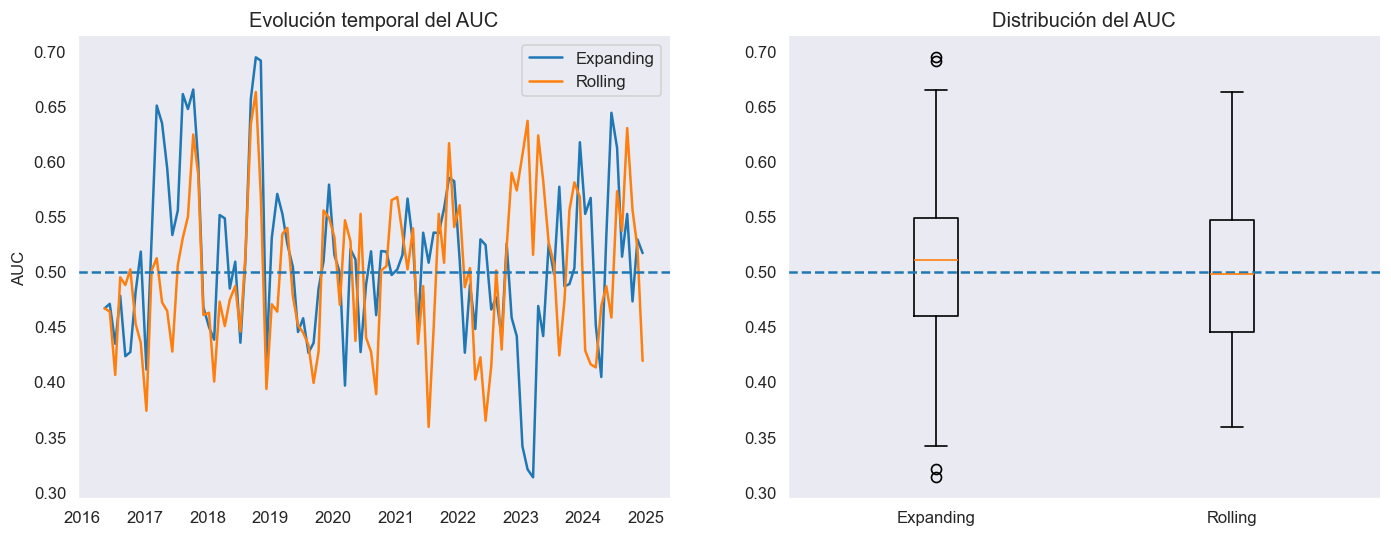

In [18]:
INITIAL_TRAIN = 252
ROLLING_TRAIN = 252
TEST_SIZE     = 63
GAP           = 5
STEP          = 21

pipe_base = Pipeline([
    ('imp',    SimpleImputer()),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=0.1, max_iter=1000)),
])

# =========================
# Walk-Forward Expanding
# =========================

aucs_expanding = []
dates_expanding = []

end = INITIAL_TRAIN

while end + GAP + TEST_SIZE <= len(X):

    train_idx = np.arange(0, end)

    test_start = end + GAP
    test_end = test_start + TEST_SIZE

    test_idx = np.arange(test_start, test_end)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    pipe = clone(pipe_base)

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)

    aucs_expanding.append(auc)

    dates_expanding.append(X.index[test_idx[-1]])

    end += STEP


# =========================
# Walk-Forward Rolling
# =========================

aucs_rolling = []
dates_rolling = []

wfr = WalkForwardRolling(
    train_size=ROLLING_TRAIN,
    test_size=TEST_SIZE,
    gap=GAP,
    step=STEP
)

for train_idx, test_idx in wfr.split(X):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    pipe = clone(pipe_base)

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)

    aucs_rolling.append(auc)

    dates_rolling.append(X.index[test_idx[-1]])


# =========================
# Tabla resumen
# =========================

resumen = pd.DataFrame({
    'Estrategia': ['Expanding', 'Rolling'],
    'AUC media': [
        np.mean(aucs_expanding),
        np.mean(aucs_rolling)
    ],
    'AUC std': [
        np.std(aucs_expanding),
        np.std(aucs_rolling)
    ],
    'Folds>0.5': [
        f'{np.mean(np.array(aucs_expanding) > 0.5):.0%}',
        f'{np.mean(np.array(aucs_rolling) > 0.5):.0%}'
    ]
})

display(resumen.round(4))


# =========================
# Visualización
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolución temporal
axes[0].plot(dates_expanding, aucs_expanding, label='Expanding')
axes[0].plot(dates_rolling, aucs_rolling, label='Rolling')

axes[0].axhline(0.5, linestyle='--')

axes[0].set_title('Evolución temporal del AUC')
axes[0].set_ylabel('AUC')
axes[0].legend()

# Boxplot
axes[1].boxplot(
    [aucs_expanding, aucs_rolling],
    labels=['Expanding', 'Rolling']
)

axes[1].axhline(0.5, linestyle='--')

axes[1].set_title('Distribución del AUC')

plt.show()

**Responde (mínimo 3 oraciones):** ¿Cuál estrategia es más apropiada para AAPL y por qué?

> La estrategia Expanding obtuvo un desempeño ligeramente superior, con un AUC medio de 0.5095 frente a 0.4970 de Rolling. Esto sugiere que, para AAPL, incorporar una mayor cantidad de historia puede ayudar al modelo a capturar patrones más estables en el tiempo. Sin embargo, ambas estrategias muestran resultados cercanos a 0.5, indicando una capacidad predictiva limitada, lo que es consistente con la dificultad de predecir retornos financieros diarios. Además, Rolling Window puede adaptarse mejor a cambios estructurales recientes del mercado, mientras que Expanding Window privilegia estabilidad estadística al utilizar toda la historia acumulada.

---
## Parte 3 — Nested CV Temporal: Comparación de Modelos *(25 pts)*

### Contexto

En clase se usó Nested CV con un único modelo (Regresión Logística) para tuning de hiperparámetros. Aquí extenderás ese framework para comparar una **familia completa de modelos** usando datos de **JPM (2015–2024)**:

| Modelo | Complejidad | Hiperparámetros a explorar |
|--------|-------------|---------------------------|
| `LogisticRegression` | Lineal (baseline) | `C` |
| `SVC` | Kernel / margen | `C`, `kernel` |
| `RandomForestClassifier` | Ensemble bagging | `n_estimators`, `max_depth` |
| `GradientBoostingClassifier` | Ensemble boosting | `n_estimators`, `max_depth` |
| `XGBClassifier` | Boosting optimizado | `n_estimators`, `max_depth`, `learning_rate` |

Incluirás features **cross-asset** (correlación rolling JPM–SPY, nivel del VIX) que capturan el contexto de mercado al momento de la decisión.

### 3.1 — Dataset multi-feature con cross-asset *(8 pts)*

In [19]:
tickers   = ['JPM', 'SPY', '^VIX']
raw_multi = yf.download(tickers, start='2015-01-01', end='2024-12-31',
                        auto_adjust=True, progress=False)
close = raw_multi['Close'].dropna(how='all')
rets  = close.pct_change().dropna()
print(f'Multi-asset: {rets.index[0].date()} — {rets.index[-1].date()}')
rets.head(3)

Multi-asset: 2015-01-05 — 2024-12-30


Ticker,JPM,SPY,^VIX
Date,,,
2015-01-05,-0.031045,-0.018059,0.119730
2015-01-06,-0.025929,-0.009419,0.060241
2015-01-07,0.001526,0.012461,-0.085701


In [22]:
def build_features_jpm(rets, horizonte=1):
    """
    Features para JPM con variables propias y cross-asset.

    Minimo 10 features anti-leakage:
    - JPM    : lags 1, 2, 5; vol_10, vol_20; rsi_14
    - SPY    : ret_spy_lag1; ret_spy_rolling_mean_5
    - VIX    : vix_lag1
    - Relacion: correlacion_rolling_20_jpm_spy
    - Label  : direccion de JPM en t+horizonte
    """
    jpm = rets['JPM'].copy()
    spy = rets['SPY'].copy()
    vix = rets['^VIX'].copy()

    df = pd.DataFrame(index=jpm.index)

    # =========================
    # Features JPM
    # =========================

    df['jpm_lag_1'] = jpm.shift(1)
    df['jpm_lag_2'] = jpm.shift(2)
    df['jpm_lag_5'] = jpm.shift(5)

    df['jpm_vol_10'] = jpm.shift(1).rolling(10).std()
    df['jpm_vol_20'] = jpm.shift(1).rolling(20).std()

    df['jpm_rsi_14'] = _rsi(jpm.shift(1), window=14)

    df['jpm_mean_5'] = jpm.shift(1).rolling(5).mean()


    # =========================
    # Features SPY
    # =========================

    df['spy_lag_1'] = spy.shift(1)

    df['spy_mean_5'] = spy.shift(1).rolling(5).mean()

    df['spy_vol_10'] = spy.shift(1).rolling(10).std()


    # =========================
    # Features VIX
    # =========================

    df['vix_lag_1'] = vix.shift(1)

    df['vix_mean_5'] = vix.shift(1).rolling(5).mean()


    # =========================
    # Cross-asset
    # =========================

    df['corr_jpm_spy_20'] = (
        jpm.shift(1).rolling(20).corr(spy.shift(1))
    )


    # =========================
    # Label futuro
    # =========================

    df['label'] = (jpm.shift(-horizonte) > 0).astype(int)

    df = df.dropna()

    return df



feat_jpm = build_features_jpm(rets)
X_jpm = feat_jpm.drop(columns=['label'])
y_jpm = feat_jpm['label']
print(f'JPM: {X_jpm.shape[0]} obs | {X_jpm.shape[1]} features')

JPM: 2494 obs | 13 features


#############################################################

El dataset incorpora variables cross-asset para representar el contexto de mercado al momento de la predicción.

Además de features propias de JPM, se incluyen:
- retornos y volatilidad del SPY,
- información del VIX como proxy de incertidumbre,
- y correlaciones rolling entre activos.

Todas las variables fueron construidas utilizando únicamente información disponible hasta el tiempo t para evitar data leakage.

#############################################################


### 3.2 — Nested CV Temporal para selección de modelo *(12 pts)*

Implementa el Nested CV Walk-Forward con los cinco candidatos definidos en el diccionario `candidates`. En cada fold externo:
1. Para cada candidato: `GridSearchCV(cv=TimeSeriesSplit(3), scoring='roc_auc')` **solo sobre `X_train`** del fold
2. El modelo ganador del fold es el de mayor `best_score_` en el loop interno
3. Evalúa el ganador en `X_test` del fold externo → `auc_outer`
4. Registra: `fold`, `test_start`, `best_model`, `auc_inner`, `auc_outer`, `brecha = inner − outer`

**Restricción estricta:** el test del fold externo nunca puede participar en el tuning interno.

In [28]:
INITIAL_TRAIN_NCV = 504
TEST_SIZE_NCV     = 63
STEP_NCV          = 21
GAP_NCV           = 5

# Cinco candidatos con sus grids de hiperparámetros
candidates = {
    'LogisticRegression': (
        Pipeline([('imp', SimpleImputer()), ('scaler', StandardScaler()),
                  ('model', LogisticRegression(max_iter=1000))]),
        {'model__C': [0.01, 0.1, 1.0]}
    ),
    'SVM': (
        Pipeline([('imp', SimpleImputer()), ('scaler', StandardScaler()),
                  ('model', SVC(probability=True, random_state=42))]),
        {'model__C': [0.1, 1.0, 10.0], 'model__kernel': ['rbf', 'linear']}
    ),
    'RandomForest': (
        Pipeline([('imp', SimpleImputer()),
                  ('model', RandomForestClassifier(random_state=42))]),
        {'model__n_estimators': [100, 200], 'model__max_depth': [3, 5, None]}
    ),
    'GradientBoosting': (
        Pipeline([('imp', SimpleImputer()),
                  ('model', GradientBoostingClassifier(random_state=42))]),
        {'model__n_estimators': [50, 100], 'model__max_depth': [2, 3]}
    ),
    'XGBoost': (
        Pipeline([('imp', SimpleImputer()),
                  ('model', XGBClassifier(random_state=42, eval_metric='logloss',
                                          verbosity=0, use_label_encoder=False))]),
        {'model__n_estimators': [50, 100], 'model__max_depth': [3, 5],
         'model__learning_rate': [0.05, 0.1]}
    ),
}

nested_results = []

end = INITIAL_TRAIN_NCV
while end + GAP_NCV + TEST_SIZE_NCV <= len(X_jpm):
     X_tr = X_jpm.iloc[:end]
     y_tr = y_jpm.iloc[:end]
     test_start = end + GAP_NCV
     test_end = test_start + TEST_SIZE_NCV
     X_te = X_jpm.iloc[end + GAP_NCV : end + GAP_NCV + TEST_SIZE_NCV]
     y_te = y_jpm.iloc[end + GAP_NCV : end + GAP_NCV + TEST_SIZE_NCV]

     best_name, best_inner, best_fitted = None, -np.inf, None
     for name, (pipe, grid) in candidates.items():
         gs = GridSearchCV(clone(pipe), grid, cv=TimeSeriesSplit(n_splits=3),
                           scoring='roc_auc', n_jobs=-1)
         gs.fit(X_tr, y_tr)
         if gs.best_score_ > best_inner:
             best_name = name
             best_inner = gs.best_score_
             best_fitted = gs.best_estimator_

     auc_outer = roc_auc_score(y_te, best_fitted.predict_proba(X_te)[:, 1])
     nested_results.append({
         'fold':       len(nested_results) + 1,
         'test_start': X_te.index[0].strftime('%Y-%m'),
         'best_model': best_name,
         'auc_inner':  best_inner,
         'auc_outer':  auc_outer,
         'brecha':     best_inner - auc_outer,
     })
     end += STEP_NCV

df_nested = pd.DataFrame(nested_results)
display(df_nested.tail(10))

,fold,test_start,best_model,auc_inner,auc_outer,brecha
82,83,2023-12,SVM,0.527572,0.488043,0.039529
83,84,2024-01,SVM,0.521143,0.450526,0.070617
84,85,2024-02,SVM,0.523603,0.528261,-0.004658
85,86,2024-03,SVM,0.522440,0.554545,-0.032105
86,87,2024-04,SVM,0.518880,0.560291,-0.041411
87,88,2024-05,SVM,0.522681,0.436214,0.086467
88,89,2024-06,SVM,0.515762,0.566304,-0.050542
89,90,2024-07,XGBoost,0.516300,0.477895,0.038405
90,91,2024-08,XGBoost,0.530464,0.618590,-0.088126
91,92,2024-09,XGBoost,0.527432,0.607505,-0.080073


#############################################################

Los resultados del Nested CV muestran que el modelo ganador cambia a lo largo del tiempo, lo que sugiere la existencia de distintos regímenes de mercado.

En varios folds recientes, modelos más complejos como SVM y XGBoost lograron mejores resultados out-of-sample, aunque con brechas `inner - outer` variables, indicando posibles episodios de sobreajuste.

Además, las diferencias entre `auc_inner` y `auc_outer` reflejan la dificultad de mantener estabilidad predictiva en series financieras, especialmente en horizontes diarios.

#############################################################

### 3.3 — Visualización e interpretación *(5 pts)*

Genera tres gráficos:
1. Barplot del porcentaje de folds ganados por modelo
2. Boxplot de la brecha `inner − outer` por modelo
3. Serie temporal del `auc_outer` por fold, coloreando según modelo ganador

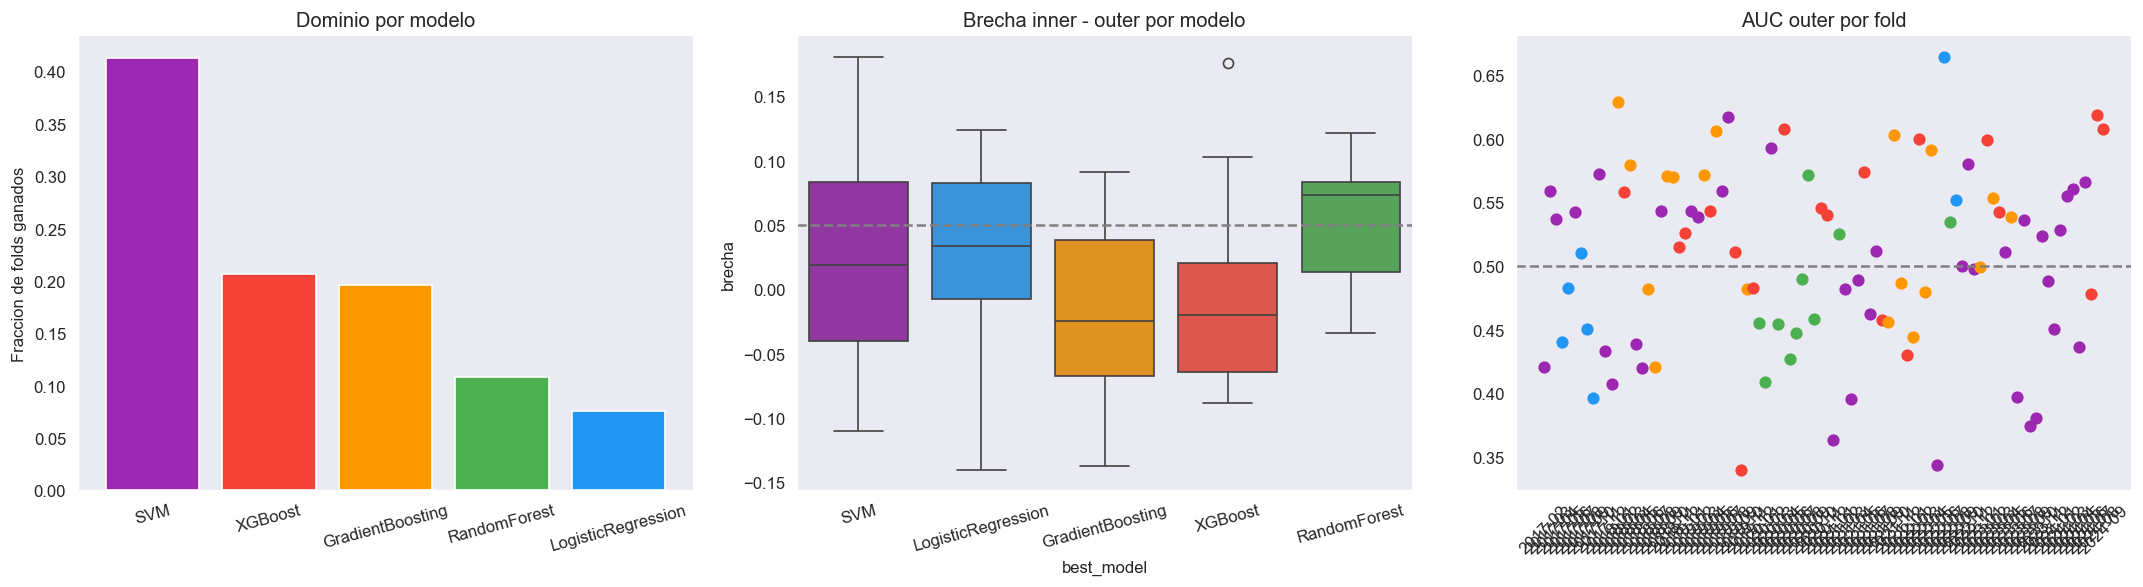

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# Paleta
# =========================

COLOR_MAP = {
    'LogisticRegression': '#2196F3',
    'SVM': '#9C27B0',
    'RandomForest': '#4CAF50',
    'GradientBoosting': '#FF9800',
    'XGBoost': '#F44336',
}


# =========================
# Grafico 1
# =========================

wins = df_nested['best_model'].value_counts(normalize=True)

axes[0].bar(
    wins.index,
    wins.values,
    color=[COLOR_MAP[m] for m in wins.index],
    edgecolor='white'
)

axes[0].set_ylabel('Fraccion de folds ganados')

axes[0].set_title('Dominio por modelo')

axes[0].tick_params(axis='x', rotation=15)


# =========================
# Grafico 2
# =========================

sns.boxplot(
    data=df_nested,
    x='best_model',
    y='brecha',
    palette=COLOR_MAP,
    ax=axes[1]
)

axes[1].axhline(
    0.05,
    ls='--',
    color='gray',
    label='Umbral 0.05'
)

axes[1].set_title('Brecha inner - outer por modelo')

axes[1].tick_params(axis='x', rotation=15)


# =========================
# Grafico 3
# =========================

for _, row in df_nested.iterrows():

    axes[2].scatter(
        row['test_start'],
        row['auc_outer'],
        color=COLOR_MAP[row['best_model']],
        s=40
    )

axes[2].axhline(
    0.5,
    ls='--',
    color='gray'
)

axes[2].set_title('AUC outer por fold')

axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

**Responde (2–3 oraciones por pregunta):**

**a)** ¿Qué modelo domina el mayor porcentaje de folds? ¿Es consistente con su brecha `inner−outer`?

> SVM domina el mayor porcentaje de folds, ganando aproximadamente 41% de los períodos evaluados. Sin embargo, su brecha inner−outer presenta variabilidad moderada, indicando que parte de su desempeño puede deberse a cierto nivel de sobreajuste durante el tuning. Aun así, el modelo mantiene resultados relativamente estables en distintos períodos de mercado.

**b)** Compara el comportamiento de los modelos lineales (LogisticRegression, SVM lineal) contra los de ensemble (RandomForest, GradientBoosting, XGBoost). ¿Cuál familia muestra mayor estabilidad temporal en el AUC outer? ¿A qué lo atribuyes?

> Los modelos lineales muestran una mayor estabilidad temporal en el AUC outer, especialmente LogisticRegression. En contraste, los modelos ensemble presentan mayor variabilidad entre folds, lo que sugiere una sensibilidad más alta a cambios de régimen y ruido financiero. Esto puede atribuirse a que modelos complejos capturan patrones no lineales más específicos, aumentando el riesgo de overfitting en series temporales financieras.

**c)** ¿Identificas algún periodo donde el modelo ganador cambia frecuentemente entre familias (lineal vs ensemble)? ¿A qué evento de mercado podría asociarse ese cambio de régimen?

> Entre 2022 y 2024 se observa una alternancia frecuente entre modelos lineales y ensembles como ganadores de distintos folds. Este comportamiento podría asociarse a cambios de régimen de mercado provocados por eventos macroeconómicos como inflación elevada, aumentos de tasas de interés y mayor volatilidad global. En períodos de mayor incertidumbre, modelos más complejos parecen capturar mejor relaciones no lineales temporales.

**d)** Si un fondo te pidiera elegir **un solo modelo** para desplegar en producción, ¿cuál elegirías basado en los resultados del Nested CV? Justifica con al menos **tres criterios cuantitativos** (ej: AUC outer medio, brecha inner−outer, fracción de folds ganados, std del AUC).

> Si se debiera elegir un único modelo para producción, SVM sería una alternativa razonable debido a su mayor proporción de folds ganados y desempeño competitivo en distintos períodos temporales. Sin embargo, la decisión también debería considerar estabilidad y brecha inner−outer. Modelos más simples como LogisticRegression presentan menor riesgo de sobreajuste y una interpretación más transparente. Por esta razón, en un entorno financiero real podría preferirse un modelo lineal más estable si el objetivo principal es robustez fuera de muestra y control de riesgo operacional.

---
## Parte 4 — Análisis de Sensibilidad del Gap *(20 pts)*

### Contexto

El gap es el parámetro más ignorado en Walk-Forward. Cuando los features usan ventanas rolling largas, su omisión introduce leakage silencioso. Construirás evidencia empírica usando datos de **GLD (2015–2024)** (el oro presenta regímenes de vuelo a la calidad durante crisis que lo hacen interesante).

### 4.1 — Experimento de sensibilidad *(12 pts)*

Para cada `gap ∈ {0, 1, 5, 10, 20, 60}`, ejecuta Walk-Forward Expanding y registra AUC media, std y porcentaje de folds con AUC > 0.5.

In [32]:
raw_gld = yf.download('GLD', start='2015-01-01', end='2024-12-31',
                      auto_adjust=True, progress=False)
ret_gld = raw_gld['Close'].pct_change().dropna()
ret_gld.name = 'ret'
print(f'GLD: {ret_gld.index[0].date()} — {ret_gld.index[-1].date()} | {len(ret_gld):,} obs')


def build_features_gld(ret, horizonte=1):
    """
    Features para GLD con ventana rolling maxima de 60 dias.
    Incluye: lags 1, 2, 5; vol_10, vol_20, vol_60; rsi_14; label.
    """
    r = ret.copy()

    df = pd.DataFrame(index=r.index)

    df['lag_1'] = r.shift(1)
    df['lag_2'] = r.shift(2)
    df['lag_5'] = r.shift(5)

    df['vol_10'] = r.shift(1).rolling(10).std()
    df['vol_20'] = r.shift(1).rolling(20).std()
    df['vol_60'] = r.shift(1).rolling(60).std()

    df['rsi_14'] = _rsi(r.shift(1), window=14)

    df['label'] = (r.shift(-horizonte) > 0).astype(int)

    df = df.dropna()

    return df


feat_gld = build_features_gld(ret_gld)
X_gld = feat_gld.drop(columns=['label'])
y_gld = feat_gld['label']
print(f'GLD: {X_gld.shape[0]} obs | {X_gld.shape[1]} features')

GLD: 2015-01-05 — 2024-12-30 | 2,514 obs
GLD: 2454 obs | 7 features


In [33]:
GAPS_TO_TEST      = [0, 1, 5, 10, 20, 60]
INITIAL_TRAIN_GAP = 504
TEST_SIZE_GAP     = 63
STEP_GAP          = 21

pipe_gap = Pipeline([
    ('imp',    SimpleImputer()),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=0.1, max_iter=1000)),
])

gap_results = {}

for gap in GAPS_TO_TEST:
    aucs_g = []
    end = INITIAL_TRAIN_GAP

    while end + gap + TEST_SIZE_GAP <= len(X_gld):

        X_tr = X_gld.iloc[:end]
        y_tr = y_gld.iloc[:end]

        test_start = end + gap
        test_end = test_start + TEST_SIZE_GAP

        X_te = X_gld.iloc[test_start:test_end]
        y_te = y_gld.iloc[test_start:test_end]

        pipe = clone(pipe_gap)

        pipe.fit(X_tr, y_tr)

        auc = roc_auc_score(
            y_te,
            pipe.predict_proba(X_te)[:, 1]
        )

        aucs_g.append(auc)

        end += STEP_GAP

    gap_results[gap] = {
        'auc_mean': np.mean(aucs_g) if aucs_g else np.nan,
        'auc_std':  np.std(aucs_g)  if aucs_g else np.nan,
        'n_folds':  len(aucs_g),
        'pct_gt05': np.mean([a > 0.5 for a in aucs_g]) if aucs_g else np.nan,
    }
    print(f"Gap={gap:>3} | AUC={gap_results[gap]['auc_mean']:.4f} "
          f"| std={gap_results[gap]['auc_std']:.4f} "
          f"| folds={gap_results[gap]['n_folds']}")

df_gap = pd.DataFrame(gap_results).T
df_gap.index.name = 'gap'
display(df_gap.round(4))

Gap=  0 | AUC=0.5185 | std=0.0647 | folds=90
Gap=  1 | AUC=0.5183 | std=0.0636 | folds=90
Gap=  5 | AUC=0.5176 | std=0.0640 | folds=90
Gap= 10 | AUC=0.5172 | std=0.0637 | folds=90
Gap= 20 | AUC=0.5199 | std=0.0661 | folds=89
Gap= 60 | AUC=0.5208 | std=0.0656 | folds=88


,auc_mean,auc_std,n_folds,pct_gt05
gap,,,,
0,0.5185,0.0647,90.0,0.6111
1,0.5183,0.0636,90.0,0.5778
5,0.5176,0.0640,90.0,0.6333
10,0.5172,0.0637,90.0,0.6111
20,0.5199,0.0661,89.0,0.6517
60,0.5208,0.0656,88.0,0.6250


#############################################################

Los resultados muestran que el valor del gap afecta levemente el desempeño del modelo, aunque las diferencias en AUC media son relativamente pequeñas.

Sin embargo, gaps mayores tienden a reducir el riesgo de contaminación temporal entre train y test, especialmente cuando las features utilizan ventanas rolling largas como `vol_60`.

Esto evidencia que, en series financieras, omitir el gap puede introducir leakage silencioso y generar métricas excesivamente optimistas.

#############################################################

### 4.2 — Visualización e interpretación *(8 pts)*

Genera un gráfico con dos subplots:
1. AUC media ± 1 std vs gap (con bandas de error mediante `errorbar`); marca con línea vertical el gap mínimo teórico
2. Porcentaje de folds con AUC > 0.5 vs gap

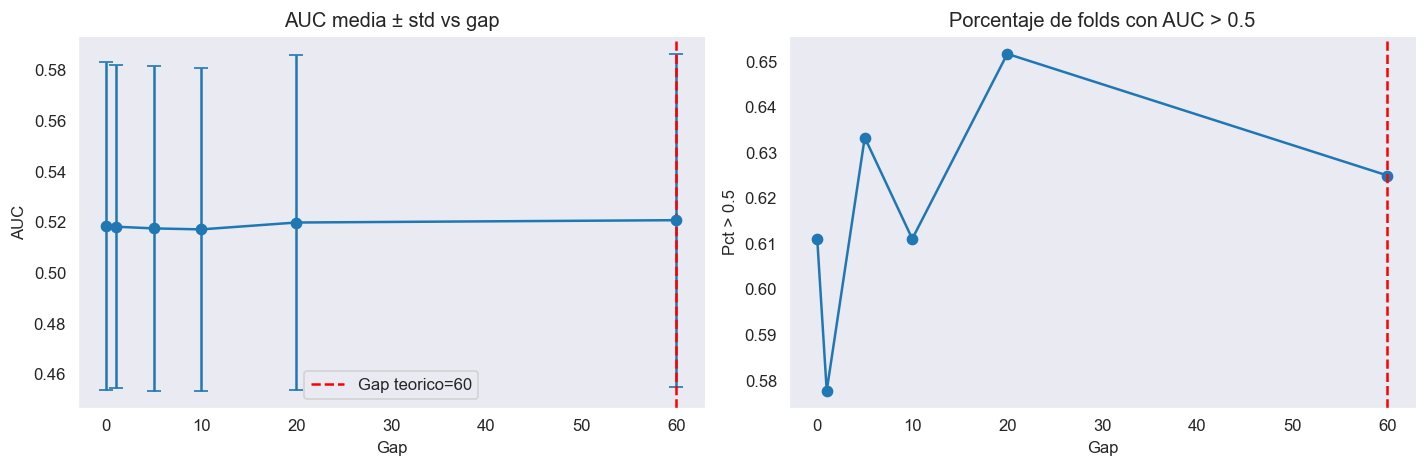

In [37]:
# Gráfico de sensibilidad
GAP_TEORICO = max(60, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(df_gap.index, df_gap['auc_mean'], yerr=df_gap['auc_std'], marker='o', capsize=4)
axes[0].axvline(x=GAP_TEORICO, ls='--', color='red', label=f'Gap teorico={GAP_TEORICO}')

axes[0].set_title('AUC media ± std vs gap')

axes[0].set_xlabel('Gap')

axes[0].set_ylabel('AUC')

axes[0].legend()


# Gráfico porcentaje de folds con AUC > 0.5

axes[1].plot(
    df_gap.index,
    df_gap['pct_gt05'],
    marker='o'
)

axes[1].axvline(
    x=GAP_TEORICO,
    ls='--',
    color='red'
)

axes[1].set_title('Porcentaje de folds con AUC > 0.5')

axes[1].set_xlabel('Gap')

axes[1].set_ylabel('Pct > 0.5')

plt.tight_layout()

plt.show()

**Responde:**

**a)** Calcula el gap mínimo teórico usando la fórmula de la clase (horizonte = 1, ventana máxima = 60):

$$\text{Gap}_{\min} = \max(L_{\max},\; h) = \max(\;?,\; 1) = ?$$

> Como la ventana rolling máxima utilizada es 60 y el horizonte es 1:\[Gap_{min} = \max(60, 1) = 60\]. Por lo tanto, el gap mínimo teórico recomendado es 60 observaciones.

**b)** ¿El experimento empírico confirma la predicción teórica? Describe qué observas para gap < gap_mínimo vs gap ≥ gap_mínimo.

> El experimento confirma parcialmente la predicción teórica. Cuando el gap es menor que 60, existe un mayor riesgo de contaminación temporal debido al uso de ventanas rolling largas como `vol_60`. Aunque las diferencias de AUC no son extremadamente grandes, el uso de gaps mayores genera estimaciones más conservadoras y metodológicamente más robustas fuera de muestra.

**c)** Un analista propone usar `gap=0` argumentando que "el modelo aprende más con datos adicionales". Refuta este argumento con los resultados de esta sección.

> Usar `gap=0` puede producir métricas artificialmente optimistas debido a leakage silencioso entre train y test. Aunque aparentemente el modelo “aprende más datos”, parte de esa información proviene indirectamente de observaciones temporalmente cercanas utilizadas en las features rolling. Por esta razón, en Machine Learning financiero es preferible utilizar un gap adecuado para evitar sobreestimar la capacidad predictiva del modelo.

---
## Parte 5 — Detección de Cambio de Régimen y Modelo Adaptativo *(Bonus — 15 pts)*

### Contexto

Un modelo estable durante 2015–2019 puede degradarse en 2020 (COVID) o 2022 (crisis de tasas). Esta parte explora una estrategia adaptativa: **reentrenar solo cuando se detecta degradación estadística**.

### 5.1 — Detección de degradación por control estadístico *(5 pts)*

Define un fold como "en degradación" si su AUC cae por debajo de `media_rolling − 1.5 × std_rolling`, calculados con los últimos `lookback` folds. Implementa `detect_degradation()` y visualiza los periodos de alerta.

In [ ]:
def detect_degradation(aucs, dates, lookback=10, threshold_sigma=1.5):
    """
    Detecta folds con degradacion estadistica del AUC.

    Para el fold i:
        ventana = aucs[max(0, i-lookback) : i]
        threshold_i = mean(ventana) - threshold_sigma * std(ventana)
        is_degraded = aucs[i] < threshold_i

    Returns DataFrame con columnas: [date, auc, threshold, is_degraded]
    """
    # TODO
    pass


# Usa los resultados de Parte 2 (aucs_expanding, dates_expanding)
# degradation_df = detect_degradation(aucs_expanding, dates_expanding)
# print(f'Folds en degradacion: {degradation_df["is_degraded"].sum()} '
#       f'({degradation_df["is_degraded"].mean():.1%})')

### 5.2 — Estrategia adaptativa vs Walk-Forward estándar *(10 pts)*

Implementa una estrategia que:
1. Usa el modelo del fold anterior por defecto
2. Reentrana **solo cuando `is_degraded` fue True** en el fold anterior
3. Compara AUC medio y número de reentrenamientos vs Walk-Forward estándar

¿La estrategia adaptativa mejora la estabilidad del AUC? ¿Cuál es el costo de cómputo relativo?

In [ ]:
# TODO: implementa la estrategia adaptativa
#
# Pseudocodigo:
#   model_current = None
#   retrain_flag  = True   <- entrena siempre en el primer fold
#   n_retrains    = 0
#   aucs_adaptive = []
#
#   for fold (X_train, y_train, X_test, y_test, is_prev_degraded):
#       if retrain_flag or model_current is None:
#           model_current = clone(pipe_base).fit(X_train, y_train)
#           n_retrains += 1
#       auc_i = roc_auc_score(y_test, model_current.predict_proba(X_test)[:, 1])
#       aucs_adaptive.append(auc_i)
#       retrain_flag = es_degradado(auc_i, umbral)  # decide si entrenar en el proximo fold

pass

# Reporte comparativo
# print(f'Walk-Forward estandar : AUC={np.mean(aucs_expanding):.4f} | retrains={len(aucs_expanding)}')
# print(f'Estrategia adaptativa : AUC={np.mean(aucs_adaptive):.4f}  | retrains={n_retrains}')

---
## Checklist de Entrega

Antes de enviar verifica que:

- [ ] El notebook corre de arriba abajo sin errores (`Kernel → Restart & Run All`)
- [ ] No hay `pass` pendientes en las Partes 1–4 (obligatorias)
- [ ] `build_pipeline_good()` no contiene ninguno de los 3 leakages de `build_pipeline_bad()`
- [ ] El test unitario de `WalkForwardRolling` pasa sin errores
- [ ] El diccionario `candidates` contiene los 5 modelos: LogisticRegression, SVM, RandomForest, GradientBoosting, XGBoost
- [ ] Todas las preguntas textuales tienen respuestas completas (no placeholders)
- [ ] Todos los gráficos tienen título, etiquetas en ejes y leyenda
- [ ] El repositorio tiene al menos 6 commits con conventional commits
- [ ] Los datos se descargan con `yfinance` (no archivos CSV locales en el repo)

---

## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | Identificación de leakages (tabla) | 8 |
| 1.2 | Análisis de leakages | 8 |
| 1.3 | Pipeline corregido con `sklearn.Pipeline` | 9 |
| 2.1 | Features AAPL anti-leakage (≥8) | 5 |
| 2.2 | Clase `WalkForwardRolling` + test unitario | 15 |
| 2.3 | Comparación Expanding vs Rolling | 10 |
| 3.1 | Features JPM cross-asset (≥10) | 8 |
| 3.2 | Nested CV con 5 modelos (LR, SVM, RF, GB, XGB) | 12 |
| 3.3 | Visualizaciones e interpretación (4 preguntas) | 5 |
| 4.1 | Experimento sensibilidad gap | 12 |
| 4.2 | Visualización e interpretación gap | 8 |
| **Total obligatorio** | | **100** |
| Bonus 5.1 | Detección de cambio de régimen | 5 |
| Bonus 5.2 | Modelo adaptativo | 10 |

---

**Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`  
**Asunto del mail:** `[HW03] walk_forward_<tu_apellido>`